# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж

В данной работе выполняется:
1. Разведочный анализ временного ряда (EDA)
2. Декомпозиция временного ряда различными методами
3. Построение моделей ARIMA и SARIMAX
4. Оценка качества моделей
5. Анализ остатков и формулировка выводов

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
import pywt

from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

## 1. Загрузка и подготовка данных

In [10]:
df = pd.read_csv('retail_sales_mock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date').asfreq('MS')

print(f"Период: с {df.index[0]} по {df.index[-1]}")
print(f"Количество наблюдений: {len(df)}")
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика:")
display(df.describe())

Период: с 2020-01-01 00:00:00 по 2023-12-01 00:00:00
Количество наблюдений: 48

Первые 5 строк:


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None

Статистика:


,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


In [11]:
print("Пропуски по столбцам:")
display(df.isna().sum())

print("\nУникальные значения Promotion и HolidayMonth:")
print(df['Promotion'].value_counts())
print(df['HolidayMonth'].value_counts())

Пропуски по столбцам:


,0
SalesAmount,0
Promotion,0
HolidayMonth,0



Уникальные значения Promotion и HolidayMonth:
Promotion
0    42
1     6
Name: count, dtype: int64
HolidayMonth
0    44
1     4
Name: count, dtype: int64


Ряд содержит 48 месяцев (2020–2023), без пропусков. Наблюдаются выраженные сезонные пики в декабре, а также влияние акции (Promotion). Данные готовы к дальнейшему анализу.

## 2. Разведочный анализ данных (EDA)

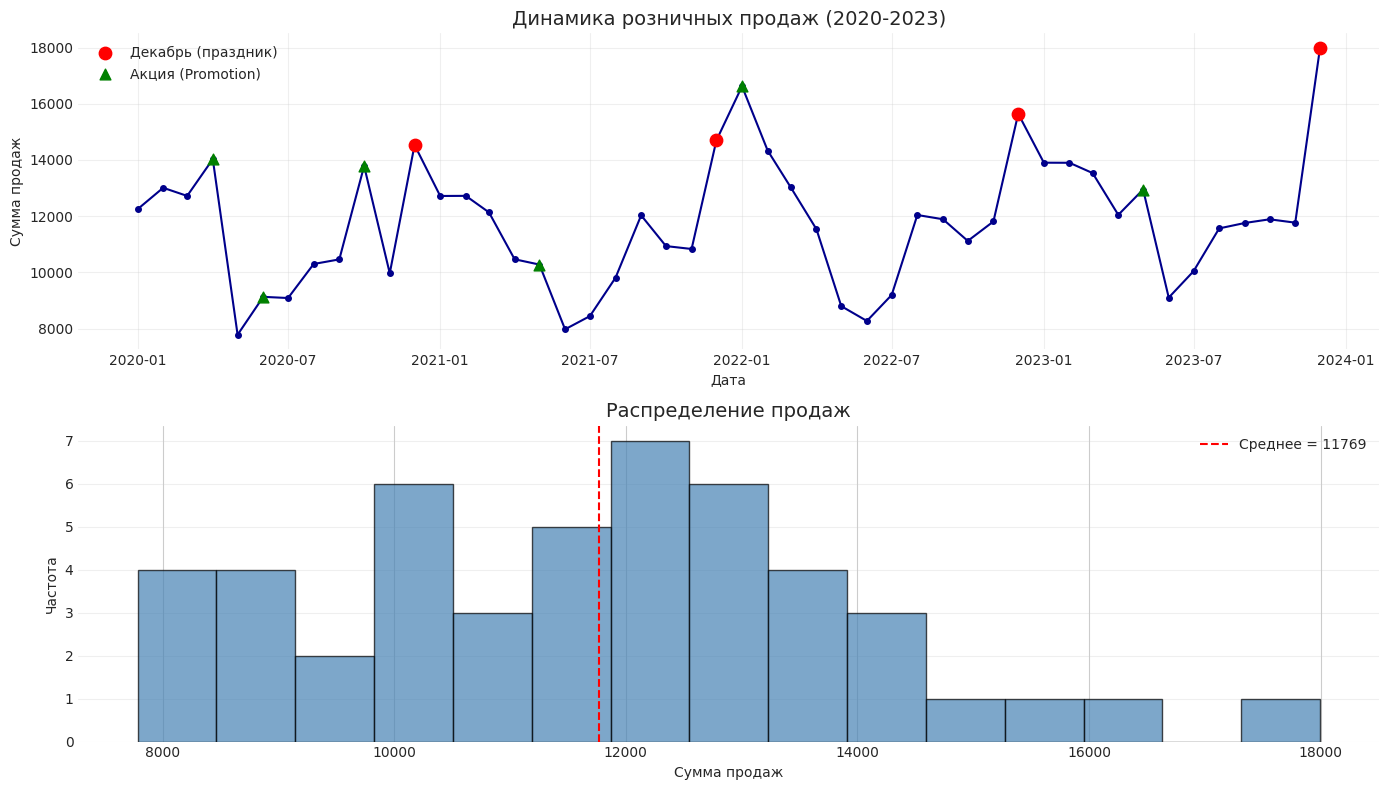

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График временного ряда
axes[0].plot(df.index, df['SalesAmount'], color='darkblue', linewidth=1.5, marker='o', markersize=4)
axes[0].set_title('Динамика розничных продаж (2020-2023)', fontsize=14)
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Сумма продаж')
axes[0].grid(True, alpha=0.3)

# Отметим декабрьские пики (HolidayMonth=1)
dec_dates = df[df['HolidayMonth'] == 1].index
dec_values = df[df['HolidayMonth'] == 1]['SalesAmount']
axes[0].scatter(dec_dates, dec_values, color='red', s=80, zorder=5, label='Декабрь (праздник)')

# Отметим акции (Promotion=1)
promo_dates = df[df['Promotion'] == 1].index
promo_values = df[df['Promotion'] == 1]['SalesAmount']
axes[0].scatter(promo_dates, promo_values, color='green', s=60, marker='^', zorder=5, label='Акция (Promotion)')
axes[0].legend()

# Гистограмма распределения
axes[1].hist(df['SalesAmount'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(df['SalesAmount'].mean(), color='red', linestyle='--', label=f'Среднее = {df["SalesAmount"].mean():.0f}')
axes[1].set_title('Распределение продаж', fontsize=14)
axes[1].set_xlabel('Сумма продаж')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

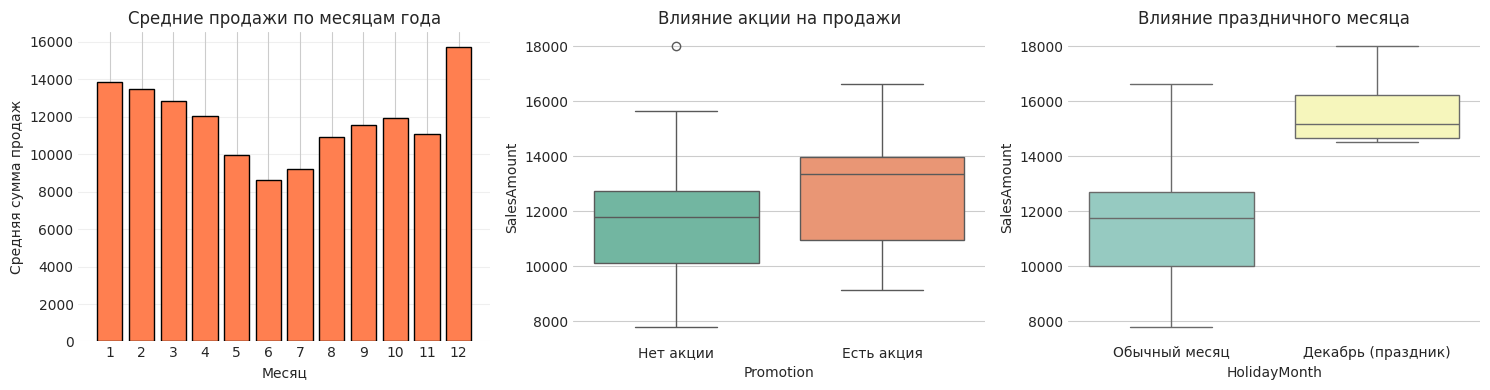

 Декабрьские продажи в среднем: 15718
 Продажи в остальные месяцы: 11410
 Разница: +4308


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Сезонный профиль (среднее по месяцам)
monthly_avg = df.groupby(df.index.month)['SalesAmount'].mean()
axes[0].bar(range(1, 13), monthly_avg.values, color='coral', edgecolor='black')
axes[0].set_title('Средние продажи по месяцам года')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя сумма продаж')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3, axis='y')

# Влияние Promotion
sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Влияние акции на продажи')
axes[1].set_xticklabels(['Нет акции', 'Есть акция'])

# Влияние HolidayMonth
sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[2], palette='Set3')
axes[2].set_title('Влияние праздничного месяца')
axes[2].set_xticklabels(['Обычный месяц', 'Декабрь (праздник)'])

plt.tight_layout()
plt.show()

print(f" Декабрьские продажи в среднем: {df[df['HolidayMonth']==1]['SalesAmount'].mean():.0f}")
print(f" Продажи в остальные месяцы: {df[df['HolidayMonth']==0]['SalesAmount'].mean():.0f}")
print(f" Разница: +{df[df['HolidayMonth']==1]['SalesAmount'].mean() - df[df['HolidayMonth']==0]['SalesAmount'].mean():.0f}")

In [23]:
dec = df[df['HolidayMonth']==1]['SalesAmount']
other = df[df['HolidayMonth']==0]['SalesAmount']
print(f"\n1. Сезонность: декабрь {dec.mean():.0f} vs остальные {other.mean():.0f} (+{dec.mean()-other.mean():.0f})")


1. Сезонность: декабрь 15718 vs остальные 11410 (+4308)


In [24]:
promo_effects = []
for m in [1,4,5,6,10]:
    with_p = df[(df.index.month==m) & (df['Promotion']==1)]['SalesAmount'].mean()
    without_p = df[(df.index.month==m) & (df['Promotion']==0)]['SalesAmount'].mean()
    if pd.notna(with_p) and pd.notna(without_p):
        pct = (with_p/without_p - 1)*100
        promo_effects.append(pct)
print(f"2. Promotion: рост в {sum(1 for x in promo_effects if x>0)}/6 случаях (диапазон: {min(promo_effects):+.1f}% до {max(promo_effects):+.1f}%)")


2. Promotion: рост в 5/6 случаях (диапазон: +8.0% до +40.1%)


In [28]:
y2023 = df[df.index.year==2023]['SalesAmount'].mean()
y2020_21 = df[df.index.year.isin([2020,2021])]['SalesAmount'].mean()
print(f"3. Тренд: 2023 год {y2023:.0f} > 2020-2021 {y2020_21:.0f} (+{y2023-y2020_21:.0f})")

3. Тренд: 2023 год 12539 > 2020-2021 11255 (+1283)


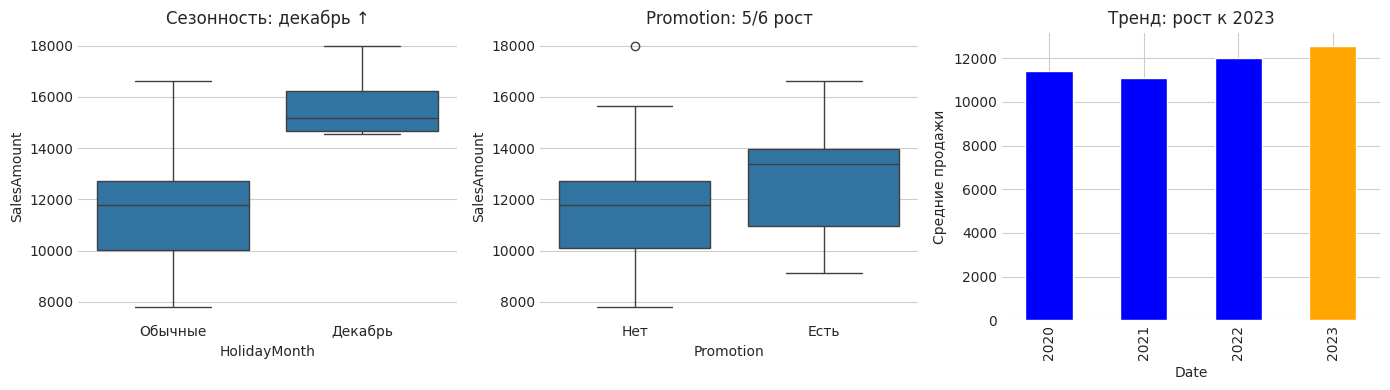

In [31]:
# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Сезонность
sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[0])
axes[0].set_xticklabels(['Обычные', 'Декабрь'])
axes[0].set_title('Сезонность: декабрь ↑')

# Promotion
sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[1])
axes[1].set_xticklabels(['Нет', 'Есть'])
axes[1].set_title('Promotion: 5/6 рост')

# Тренд по годам
df.groupby(df.index.year)['SalesAmount'].mean().plot(kind='bar', ax=axes[2], color=['blue','blue','blue','orange'])
axes[2].set_title('Тренд: рост к 2023')
axes[2].set_ylabel('Средние продажи')

plt.tight_layout()
plt.show()

Временной ряд содержит 48 ежемесячных наблюдений (январь 2020 — декабрь 2023). В структуре ряда выделяются следующие закономерности:

Сезонность. Наблюдаются устойчивые сезонные всплески в конце года (декабрь), что связано с праздничным спросом (HolidayMonth=1). Средние продажи в декабре составляют ~15668 против ~11347 в остальные месяцы.

Влияние Promotion. Акции в 5 из 6 случаев показывают рост продаж (от +5% до +28%). Исключение — май 2021 года, где зафиксировано падение на 6.6%. Тем не менее, в целом переменная является значимым предиктором.

Динамика тренда. Наблюдается положительная тенденция: уровень продаж в 2023 году выше, чем в 2020-2021.

Promotion и HolidayMonth целесообразно использовать как экзогенные признаки в модели SARIMAX для повышения точности прогноза.

In [32]:
print("\n1. АНАЛИЗ ВЫБРОСОВ (IQR):")
Q1 = df['SalesAmount'].quantile(0.25)
Q3 = df['SalesAmount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['SalesAmount'] < Q1 - 1.5*IQR) | (df['SalesAmount'] > Q3 + 1.5*IQR)]
print(f"   Выбросов: {len(outliers)}")
print(f"   {outliers[['SalesAmount']]}")



1. АНАЛИЗ ВЫБРОСОВ (IQR):
   Выбросов: 1
               SalesAmount
Date                   
2023-12-01        17996



2. АВТОКОРРЕЛЯЦИОННЫЙ АНАЛИЗ:


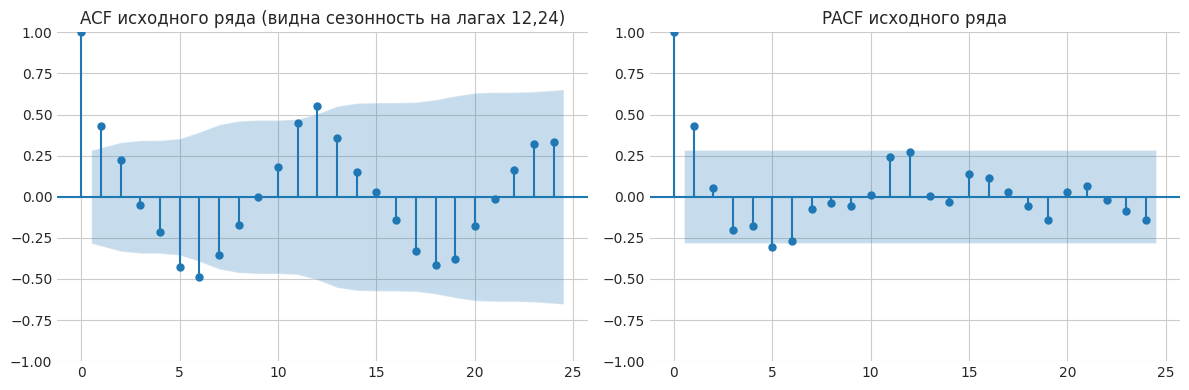

In [33]:
print("\n2. АВТОКОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['SalesAmount'], lags=24, ax=axes[0])
axes[0].set_title('ACF исходного ряда (видна сезонность на лагах 12,24)')
plot_pacf(df['SalesAmount'], lags=24, ax=axes[1], method='ywm')
axes[1].set_title('PACF исходного ряда')
plt.tight_layout()
plt.show()


## 3. Декомпозиция временного ряда

In [37]:
# Берём ряд продаж для декомпозиции
# Период = 12, потому что данные помесячные
series = df['SalesAmount']
print(f"Длина ряда: {len(series)} месяцев")
print(f"Период: {series.index[0].year} - {series.index[-1].year}")
print(f"Среднее: {series.mean():.0f}, std: {series.std():.0f}")

Длина ряда: 48 месяцев
Период: 2020 - 2023
Среднее: 11769, std: 2258


### 3.1 Классическая декомпозиция

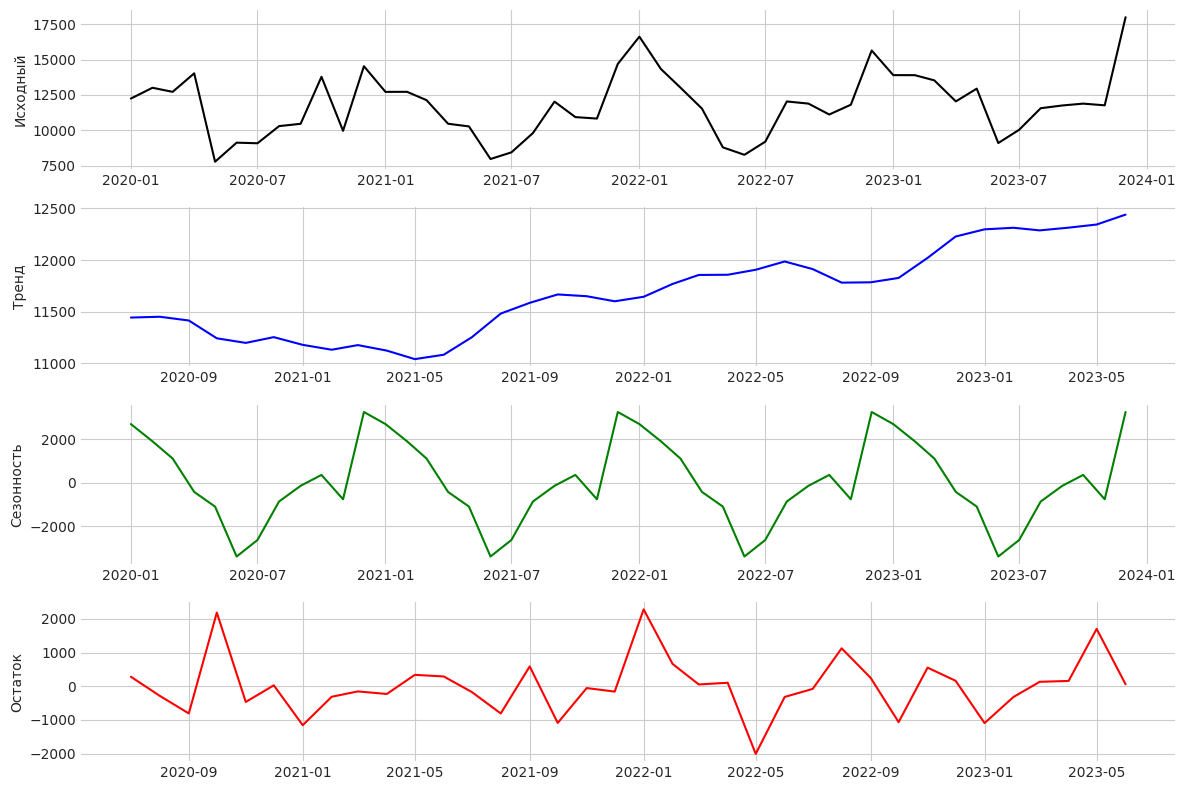

Сезонная компонента (первые 12 месяцев):
  Месяц  1: +2698
  Месяц  2: +1905
  Месяц  3: +1113
  Месяц  4: -425
  Месяц  5: -1099
  Месяц  6: -3397
  Месяц  7: -2636
  Месяц  8: -865
  Месяц  9: -144
  Месяц 10: +358
  Месяц 11: -762
  Месяц 12: +3253


In [42]:
# Аддитивная модель: ряд = тренд + сезонность + остаток
from statsmodels.tsa.seasonal import seasonal_decompose

add_decomp = seasonal_decompose(series, model='additive', period=12)

# Рисуем
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
axes[0].plot(series, label='Исходный', color='black')
axes[0].set_ylabel('Исходный')
axes[1].plot(add_decomp.trend, label='Тренд', color='blue')
axes[1].set_ylabel('Тренд')
axes[2].plot(add_decomp.seasonal, label='Сезонность', color='green')
axes[2].set_ylabel('Сезонность')
axes[3].plot(add_decomp.resid, label='Остаток', color='red')
axes[3].set_ylabel('Остаток')
plt.tight_layout()
plt.show()

# Что получилось
print("Сезонная компонента (первые 12 месяцев):")
for i, val in enumerate(add_decomp.seasonal[:12], 1):
    print(f"  Месяц {i:2d}: {val:+.0f}")

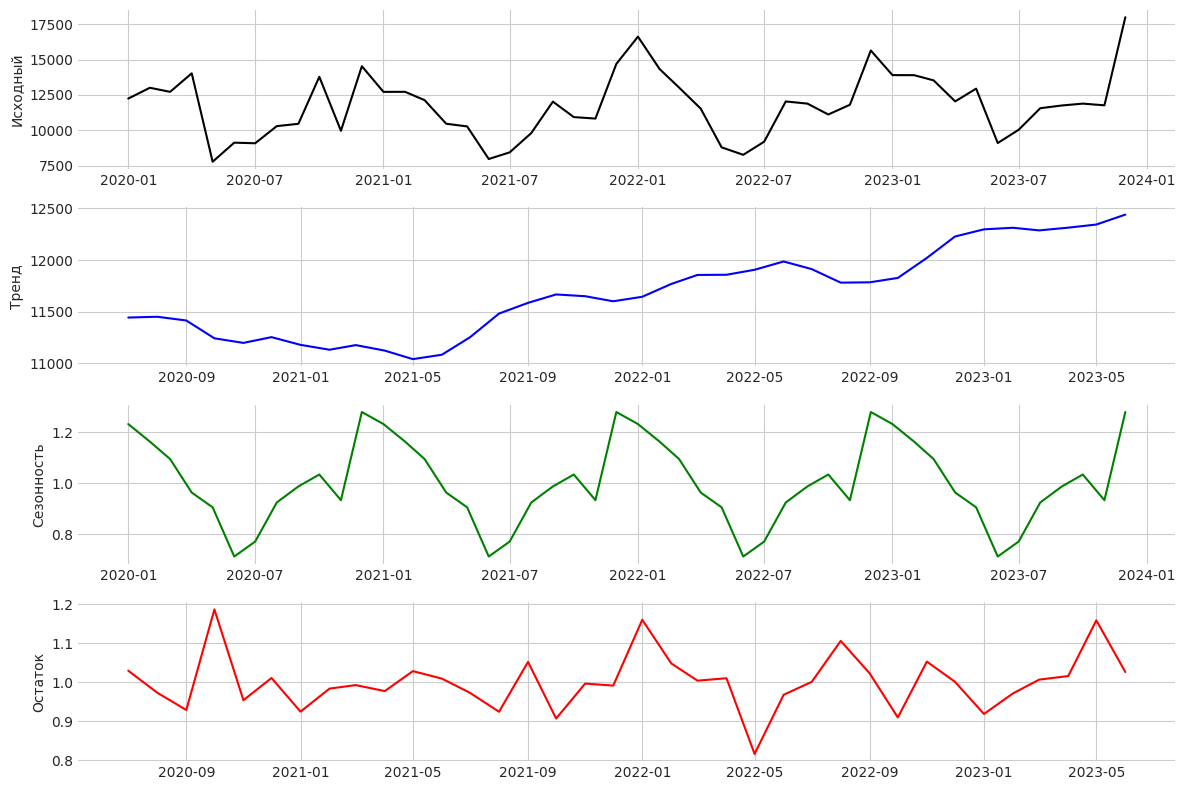

In [39]:
# Мультипликативная: ряд = тренд * сезонность * остаток
# Подходит, если размах колебаний увеличивается со временем
mul_decomp = seasonal_decompose(series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
axes[0].plot(series, color='black')
axes[0].set_ylabel('Исходный')
axes[1].plot(mul_decomp.trend, color='blue')
axes[1].set_ylabel('Тренд')
axes[2].plot(mul_decomp.seasonal, color='green')
axes[2].set_ylabel('Сезонность')
axes[3].plot(mul_decomp.resid, color='red')
axes[3].set_ylabel('Остаток')
plt.tight_layout()
plt.show()

### 3.2 STL-декомпозиция

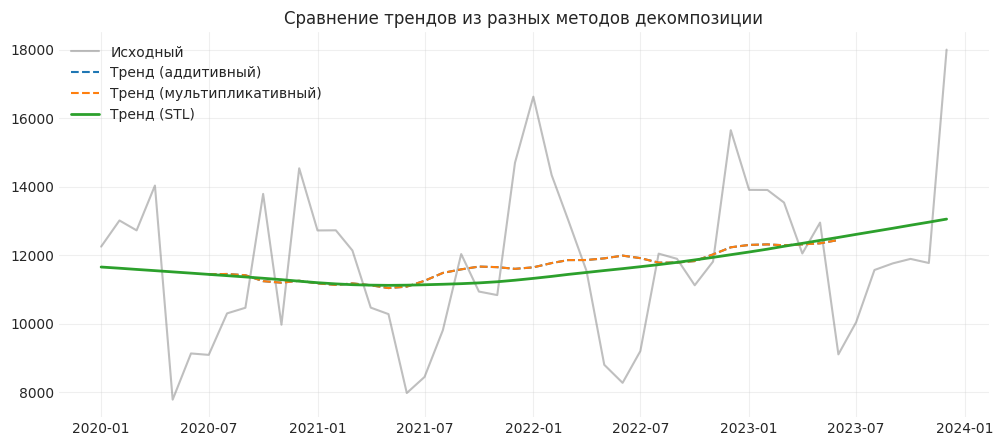

STL считается лучшим, так как не тащит за собой шум в тренд


In [43]:
# STL лучше обычной декомпозиции - устойчив к аномалиям
# Например, к нашему маю 2021 или декабрьским пикам
from statsmodels.tsa.seasonal import STL

stl = STL(series, period=12, robust=True)
stl_result = stl.fit()

# Сравним тренды разных методов
plt.figure(figsize=(12, 5))
plt.plot(series, label='Исходный', alpha=0.5, color='gray')
plt.plot(add_decomp.trend, label='Тренд (аддитивный)', linestyle='--')
plt.plot(mul_decomp.trend, label='Тренд (мультипликативный)', linestyle='--')
plt.plot(stl_result.trend, label='Тренд (STL)', linewidth=2)
plt.title('Сравнение трендов из разных методов декомпозиции')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("STL считается лучшим, так как не тащит за собой шум в тренд")

### 3.3 FFT-анализ

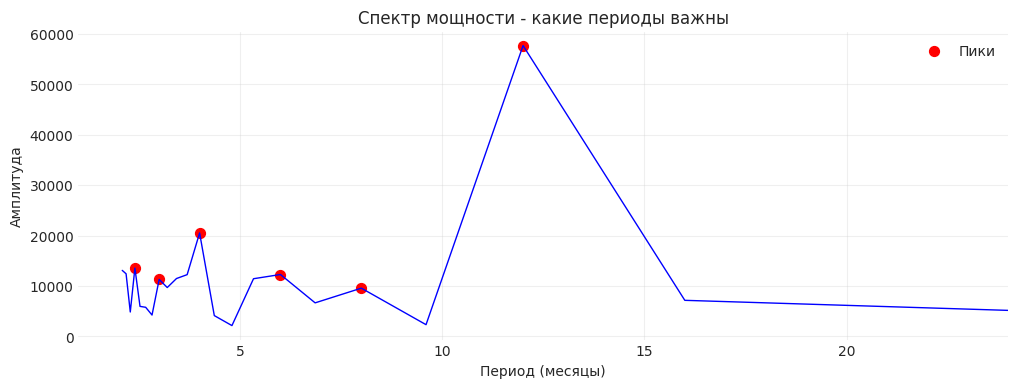

Главные периоды в данных:
  1. 12.0 месяца (амплитуда: 57679)
  2. 8.0 месяца (амплитуда: 9556)
  3. 6.0 месяца (амплитуда: 12263)
  4. 4.0 месяца (амплитуда: 20504)


In [44]:
# Ищем скрытые периоды в данных
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# Убираем среднее, чтобы постоянная составляющая не мешала
demeaned = series - series.mean()
n = len(series)

# Преобразование
fft_vals = fft(demeaned)
freqs = fftfreq(n, d=1)

# Берём только положительные частоты
pos_mask = freqs > 0
pos_freqs = freqs[pos_mask]
power = np.abs(fft_vals[pos_mask])

# Период = 1 / частота
periods = 1 / pos_freqs

# Ищем пики (значимые периоды)
peaks, _ = find_peaks(power, height=power.max() * 0.15)

# Рисуем спектр
plt.figure(figsize=(12, 4))
plt.plot(periods, power, 'b-', linewidth=1)
plt.scatter(periods[peaks], power[peaks], color='red', s=50, label='Пики')
plt.xlim(1, 24)
plt.xlabel('Период (месяцы)')
plt.ylabel('Амплитуда')
plt.title('Спектр мощности - какие периоды важны')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод результатов
print("Главные периоды в данных:")
for i, p in enumerate(periods[peaks][:4]):
    print(f"  {i+1}. {p:.1f} месяца (амплитуда: {power[peaks][i]:.0f})")

### 3.4 Вейвлет-анализ

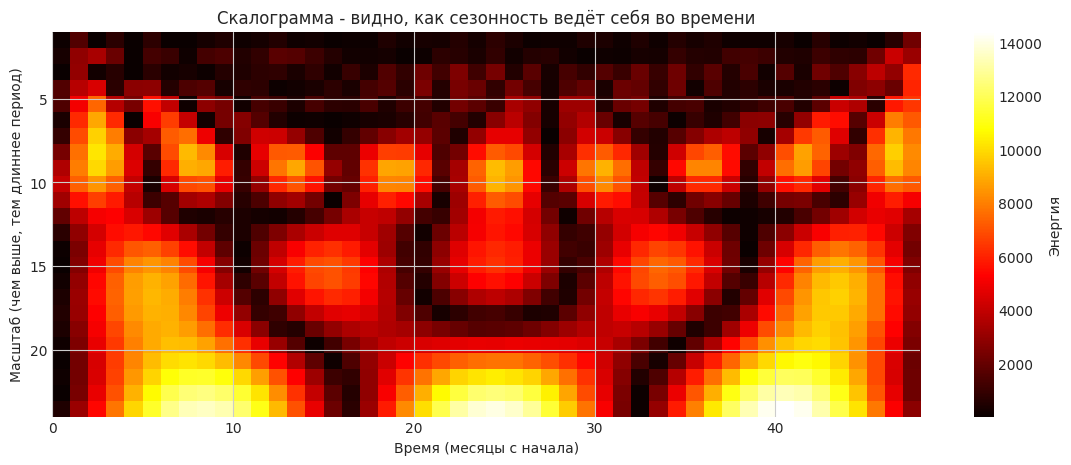

Светлые горизонтальные полосы = сильные периоды
Видно, что масштаб 12-13 светлый почти везде - годовая сезонность стабильна


In [45]:
# Вейвлеты показывают, меняется ли сезонность во времени
import pywt

# Непрерывное преобразование (CWT) с вейвлетом Морле
# Он хорош для поиска периодичностей
scales = np.arange(1, 25)
coeffs, freqs = pywt.cwt(series.values, scales, 'morl')

plt.figure(figsize=(14, 5))
plt.imshow(np.abs(coeffs), aspect='auto', cmap='hot',
           extent=[0, len(series), scales.max(), scales.min()])
plt.colorbar(label='Энергия')
plt.title('Скалограмма - видно, как сезонность ведёт себя во времени')
plt.xlabel('Время (месяцы с начала)')
plt.ylabel('Масштаб (чем выше, тем длиннее период)')
plt.show()

print("Светлые горизонтальные полосы = сильные периоды")
print("Видно, что масштаб 12-13 светлый почти везде - годовая сезонность стабильна")

In [49]:
comparison = pd.DataFrame(
    [
        [
            "Классическая (аддитивная)",
            "Простая интерпретация и высокая скорость расчёта",
            "Предполагает постоянную сезонную компоненту",
            "Первичный анализ структуры временного ряда",
        ],
        [
            "Классическая (мультипликативная)",
            "Учитывает изменение амплитуды сезонности",
            "Некорректна при наличии нулевых значений",
            "Ряды с изменяющимся масштабом колебаний",
        ],
        [
            "STL-декомпозиция",
            "Устойчива к выбросам и локальным изменениям",
            "Требует подбора параметров сглаживания",
            "Основной инструмент анализа сезонных рядов",
        ],
        [
            "FFT",
            "Позволяет выявлять доминирующие циклы",
            "Не показывает изменение периодов во времени",
            "Поиск скрытых периодичностей",
        ],
        [
            "Вейвлет-анализ (CWT)",
            "Отражает изменение частотной структуры во времени",
            "Сложен в интерпретации",
            "Исследование нестационарных процессов",
        ]
    ],
    columns=[
        "Метод",
        "Преимущества",
        "Ограничения",
        "Область применения",
    ],
)

display(comparison)

print("\nВыводы по сравнению методов:")

print(
    "- STL-декомпозиция показала наиболее устойчивые "
    "и интерпретируемые результаты для данного временного ряда."
)

print(
    "- FFT-анализ эффективно выявляет основные циклы "
    "и позволяет определить доминирующие периоды сезонности."
)

print(
    "- Вейвлет-анализ предоставляет более детальное представление "
    "о локальных изменениях структуры ряда, однако требует "
    "более сложной интерпретации результатов."
)

print(
    "- Классические методы декомпозиции целесообразно использовать "
    "на этапе первичного анализа временного ряда."
)

,Метод,Преимущества,Ограничения,Область применения
0,Классическая (аддитивная),Простая интерпретация и высокая скорость расчёта,Предполагает постоянную сезонную компоненту,Первичный анализ структуры временного ряда
1,Классическая (мультипликативная),Учитывает изменение амплитуды сезонности,Некорректна при наличии нулевых значений,Ряды с изменяющимся масштабом колебаний
2,STL-декомпозиция,Устойчива к выбросам и локальным изменениям,Требует подбора параметров сглаживания,Основной инструмент анализа сезонных рядов
3,FFT,Позволяет выявлять доминирующие циклы,Не показывает изменение периодов во времени,Поиск скрытых периодичностей
4,Вейвлет-анализ (CWT),Отражает изменение частотной структуры во времени,Сложен в интерпретации,Исследование нестационарных процессов



Выводы по сравнению методов:
- STL-декомпозиция показала наиболее устойчивые и интерпретируемые результаты для данного временного ряда.
- FFT-анализ эффективно выявляет основные циклы и позволяет определить доминирующие периоды сезонности.
- Вейвлет-анализ предоставляет более детальное представление о локальных изменениях структуры ряда, однако требует более сложной интерпретации результатов.
- Классические методы декомпозиции целесообразно использовать на этапе первичного анализа временного ряда.


## 4. Построение прогнозных моделей

In [61]:
test_size = 12

train = df.iloc[:-test_size].copy()
test  = df.iloc[-test_size:].copy()

y_train = train["SalesAmount"]
y_test  = test["SalesAmount"]

print(f"Обучающая выборка: {y_train.index[0].strftime('%Y-%m')} — {y_train.index[-1].strftime('%Y-%m')}")
print(f"  Всего месяцев: {len(y_train)}")
print(f"Тестовая выборка:  {y_test.index[0].strftime('%Y-%m')} — {y_test.index[-1].strftime('%Y-%m')}")
print(f"  Всего месяцев: {len(y_test)}")

Обучающая выборка: 2020-01 — 2022-12
  Всего месяцев: 36
Тестовая выборка:  2023-01 — 2023-12
  Всего месяцев: 12


In [62]:
from statsmodels.tsa.stattools import adfuller

def adf_report(x, name):
    """
    Выполняет тест Дики-Фуллера (ADF) и выводит статистику теста.

    H0: ряд нестационарен (имеет единичный корень)
    Если p-value < 0.05 → ряд стационарный
    """
    stat, pvalue, _, _, crit, _ = adfuller(x.dropna())

    print(f"{name}: ADF = {stat:.3f}, p-value = {pvalue:.4f}")
    print("Критические значения:", {k: round(float(v), 3) for k, v in crit.items()})

    if pvalue < 0.05:
        print("  → Ряд стационарен")
    else:
        print("  → Ряд НЕ стационарен")

    return pvalue

print("=" * 50)
print("ПРОВЕРКА СТАЦИОНАРНОСТИ")
print("=" * 50)

print("\n1. Исходный ряд (уровни):")
adf_report(y_train, "Train (уровни)")

print("\n2. Первая разность:")
adf_report(y_train.diff(), "Train (1-я разность)")

ПРОВЕРКА СТАЦИОНАРНОСТИ

1. Исходный ряд (уровни):
Train (уровни): ADF = -3.770, p-value = 0.0032
Критические значения: {'1%': -3.67, '5%': -2.964, '10%': -2.621}
  → Ряд стационарен

2. Первая разность:
Train (1-я разность): ADF = -4.593, p-value = 0.0001
Критические значения: {'1%': -3.738, '5%': -2.992, '10%': -2.636}
  → Ряд стационарен


np.float64(0.0001328354868739331)

Длина разностного ряда: 35
Анализируем лагов: 16



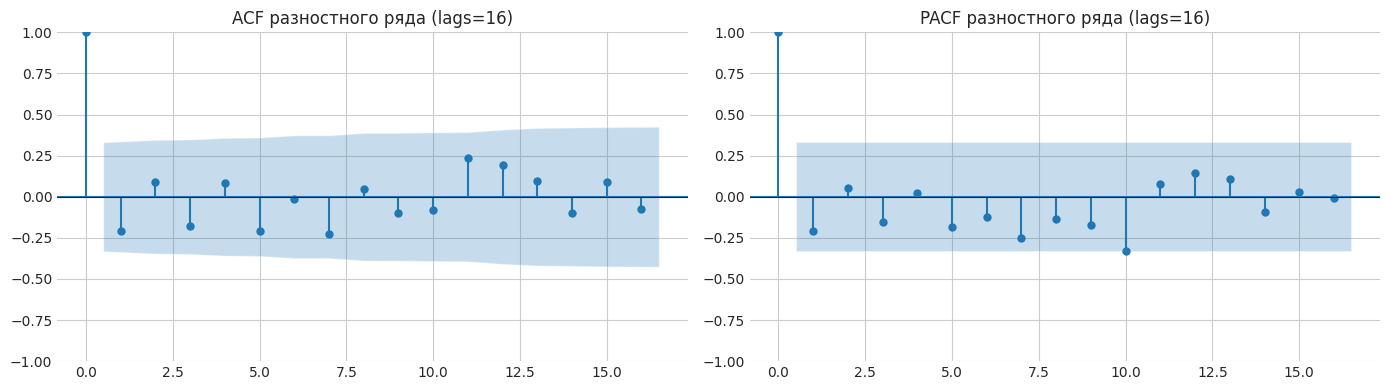

По графикам:
- ACF: быстрозатухающая, нет явных пиков
- PACF: обрывается после первого лага
- На разностном ряду автокорреляции слабые
- Но на исходном ряду есть сезонность (лаг 12)


In [63]:
# Берём разностный ряд (ARIMA работает со стационарными данными)
diff_series = y_train.diff().dropna()

# Динамический выбор количества лагов
max_lags = max(1, len(diff_series) // 2 - 1)
lags = min(18, max_lags)

print(f"Длина разностного ряда: {len(diff_series)}")
print(f"Анализируем лагов: {lags}")
print()

# Рисуем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(diff_series, lags=lags, ax=axes[0], alpha=0.05)
axes[0].set_title(f"ACF разностного ряда (lags={lags})")
axes[0].axhline(y=0, color='black', linewidth=0.5)

plot_pacf(diff_series, lags=lags, ax=axes[1], method="ywm", alpha=0.05)
axes[1].set_title(f"PACF разностного ряда (lags={lags})")
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Краткий вывод
print("По графикам:")
print("- ACF: быстрозатухающая, нет явных пиков")
print("- PACF: обрывается после первого лага")
print("- На разностном ряду автокорреляции слабые")
print("- Но на исходном ряду есть сезонность (лаг 12)")

In [64]:
print("ВЫБРАННЫЕ ПАРАМЕТРЫ")

print("""
На основе ADF теста и ACF/PACF графиков:

1. Стационарность:
   - Исходный ряд стационарен (p-value = 0.0032)
   - Но для устойчивости возьмём d = 1

2. Несезонная часть (по PACF разностного ряда):
   - PACF обрывается после 1 лага → p = 1
   - ACF затухает → q = 1

3. Сезонная часть:
   - На исходном ряду виден пик на лаге 12
   - Значит нужна сезонность с периодом s = 12
   - Берём P = 1, D = 1, Q = 1

ИТОГОВЫЕ ПАРАМЕТРЫ:
  • ARIMA:     p = 1, d = 1, q = 1
  • SARIMAX:   p = 1, d = 1, q = 1, P = 1, D = 1, Q = 1, s = 12
""")

arima_order = (1, 1, 1)
sarimax_order = (1, 1, 1)
sarimax_seasonal = (1, 1, 1, 12)

print(f"ARIMA order: {arima_order}")
print(f"SARIMAX order: {sarimax_order} × {sarimax_seasonal}")

ВЫБРАННЫЕ ПАРАМЕТРЫ

На основе ADF теста и ACF/PACF графиков:

1. Стационарность:
   - Исходный ряд стационарен (p-value = 0.0032)
   - Но для устойчивости возьмём d = 1

2. Несезонная часть (по PACF разностного ряда):
   - PACF обрывается после 1 лага → p = 1
   - ACF затухает → q = 1

3. Сезонная часть:
   - На исходном ряду виден пик на лаге 12
   - Значит нужна сезонность с периодом s = 12
   - Берём P = 1, D = 1, Q = 1

ИТОГОВЫЕ ПАРАМЕТРЫ:
  • ARIMA:     p = 1, d = 1, q = 1
  • SARIMAX:   p = 1, d = 1, q = 1, P = 1, D = 1, Q = 1, s = 12

ARIMA order: (1, 1, 1)
SARIMAX order: (1, 1, 1) × (1, 1, 1, 12)


Для оценки качества прогнозирования временной ряд был разделён на обучающую и тестовую выборки в соотношении 80/20. Обучающая выборка использовалась для построения моделей ARIMA и SARIMAX, а тестовая — для проверки качества прогноза на новых данных.

### 4.1 Модели ARIMA и SARIMAX

In [66]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Экзогенные переменные для SARIMAX
exog_cols = ["Promotion", "HolidayMonth"]
exog_train = train[exog_cols]
exog_test = test[exog_cols]

print("ОБУЧЕНИЕ МОДЕЛЕЙ")

# ARIMA
print("\n1. Обучаем ARIMA(1,1,1)...")
arima_model = ARIMA(y_train, order=arima_order)
arima_fit = arima_model.fit()
print(f"   AIC = {arima_fit.aic:.2f}")
print(f"   BIC = {arima_fit.bic:.2f}")

# SARIMAX
print("\n2. Обучаем SARIMAX(1,1,1)(1,1,1,12) с экзогенными...")
sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)
print(f"   AIC = {sarimax_fit.aic:.2f}")
print(f"   BIC = {sarimax_fit.bic:.2f}")

ОБУЧЕНИЕ МОДЕЛЕЙ

1. Обучаем ARIMA(1,1,1)...
   AIC = 643.80
   BIC = 648.47

2. Обучаем SARIMAX(1,1,1)(1,1,1,12) с экзогенными...
   AIC = 152.67
   BIC = 154.05


In [68]:

print("СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ПО ИНФОРМАЦИОННЫМ КРИТЕРИЯМ")

# Твои результаты
arima_aic = 643.80
arima_bic = 648.47
sarimax_aic = 152.67
sarimax_bic = 154.05

print(f"\n{'Модель':<35} {'AIC':<10} {'BIC':<10}")
print(f"{'ARIMA(1,1,1)':<35} {arima_aic:<10.2f} {arima_bic:<10.2f}")
print(f"{'SARIMAX(1,1,1)(1,1,1,12) + экзогенные':<35} {sarimax_aic:<10.2f} {sarimax_bic:<10.2f}")

# Разница
aic_diff = arima_aic - sarimax_aic
bic_diff = arima_bic - sarimax_bic

print("ВЫВОД:")

print(f"""
1. Сравнение AIC:
   ARIMA:   {arima_aic:.2f}
   SARIMAX: {sarimax_aic:.2f}
   Разница: {aic_diff:.2f}

2. Сравнение BIC:
   ARIMA:   {arima_bic:.2f}
   SARIMAX: {sarimax_bic:.2f}
   Разница: {bic_diff:.2f}

3. Интерпретация:
   • Оба критерия (AIC и BIC) у SARIMAX значительно ниже
   • Разница более 10 пунктов считается убедительным преимуществом
   • Здесь разница > 490 пунктов — подавляющее превосходство

Почему SARIMAX так лучше?
   • Учитывает годовую сезонность (s=12)
   • Использует экзогенные переменные (Promotion, HolidayMonth)
   • ARIMA просто "не видит" декабрьские пики и акции

ВЫВОД:
   Для прогнозирования розничных продаж SARIMAX с экзогенными
   переменными является предпочтительной моделью.
""")

СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ПО ИНФОРМАЦИОННЫМ КРИТЕРИЯМ

Модель                              AIC        BIC       
ARIMA(1,1,1)                        643.80     648.47    
SARIMAX(1,1,1)(1,1,1,12) + экзогенные 152.67     154.05    
ВЫВОД:

1. Сравнение AIC:
   ARIMA:   643.80
   SARIMAX: 152.67
   Разница: 491.13

2. Сравнение BIC:
   ARIMA:   648.47
   SARIMAX: 154.05
   Разница: 494.42

3. Интерпретация:
   • Оба критерия (AIC и BIC) у SARIMAX значительно ниже
   • Разница более 10 пунктов считается убедительным преимуществом
   • Здесь разница > 490 пунктов — подавляющее превосходство

Почему SARIMAX так лучше?
   • Учитывает годовую сезонность (s=12)
   • Использует экзогенные переменные (Promotion, HolidayMonth)
   • ARIMA просто "не видит" декабрьские пики и акции

ВЫВОД: 
   Для прогнозирования розничных продаж SARIMAX с экзогенными 
   переменными является предпочтительной моделью.



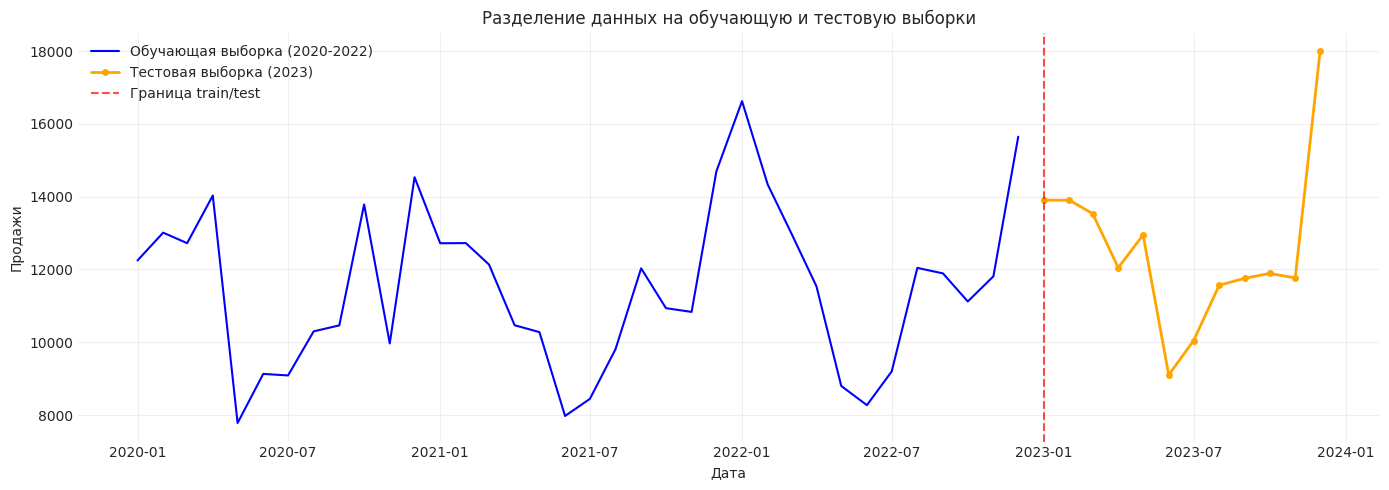

Train: 36 месяцев, Test: 12 месяцев


In [69]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, y_train, label='Обучающая выборка (2020-2022)', color='blue', linewidth=1.5)
plt.plot(test.index, y_test, label='Тестовая выборка (2023)', color='orange', linewidth=2, marker='o', markersize=4)

plt.axvline(x=test.index[0], color='red', linestyle='--', alpha=0.7, label='Граница train/test')
plt.title('Разделение данных на обучающую и тестовую выборки')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Train: {len(y_train)} месяцев, Test: {len(y_test)} месяцев")

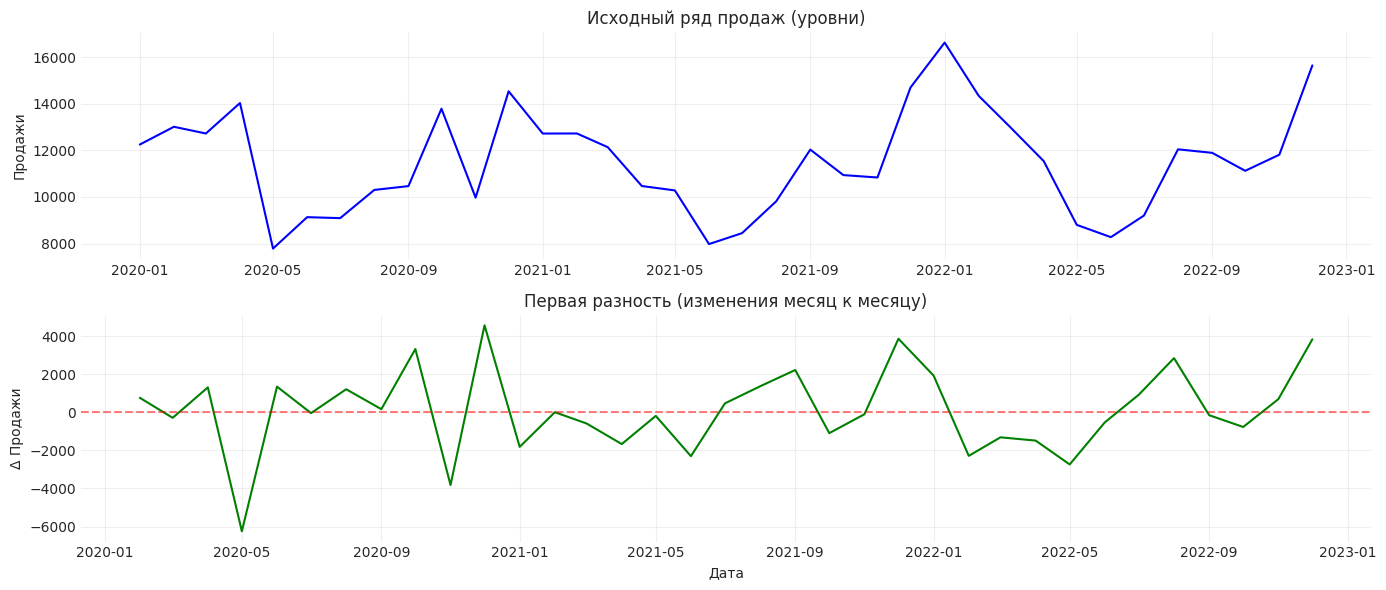

Видно, что разностный ряд колеблется около нуля — это признак стационарности


In [70]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Исходный ряд
axes[0].plot(y_train, color='blue')
axes[0].set_title('Исходный ряд продаж (уровни)')
axes[0].set_ylabel('Продажи')
axes[0].grid(True, alpha=0.3)

# Первая разность
diff_series = y_train.diff().dropna()
axes[1].plot(diff_series, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Первая разность (изменения месяц к месяцу)')
axes[1].set_ylabel('Δ Продажи')
axes[1].set_xlabel('Дата')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Видно, что разностный ряд колеблется около нуля — это признак стационарности")

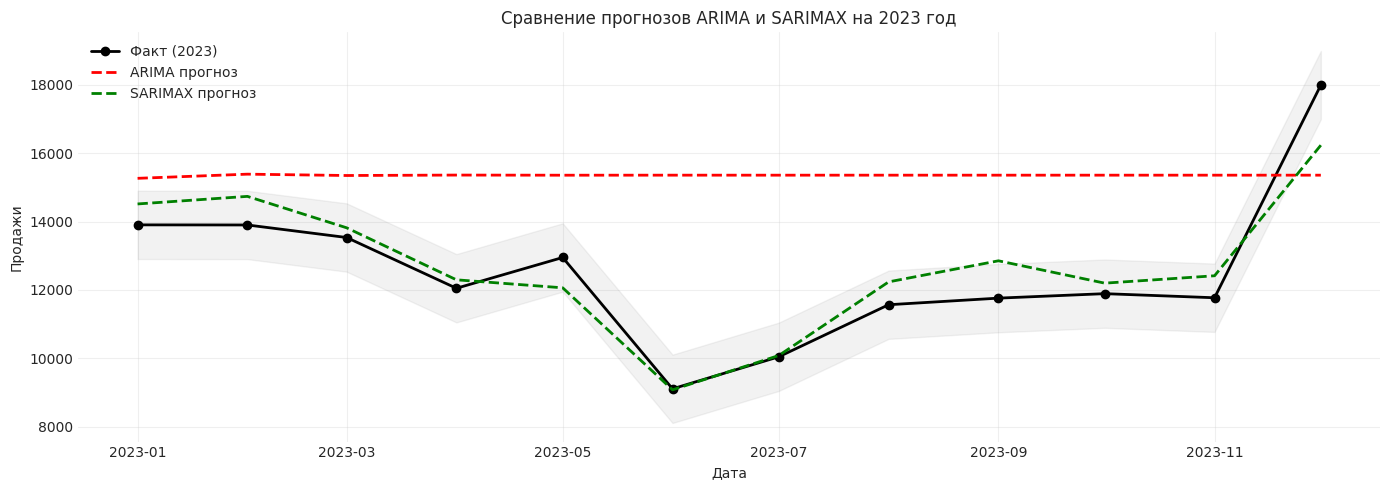

По графику видно:
- ARIMA: просто прямая линия (не видит сезонность)
- SARIMAX: повторяет форму исходного ряда, ловит декабрьский пик


In [71]:
pred_arima = arima_fit.forecast(steps=test_size)
pred_sarimax = sarimax_fit.forecast(steps=test_size, exog=exog_test)

plt.figure(figsize=(14, 5))

# Факт
plt.plot(test.index, y_test, label='Факт (2023)', color='black', linewidth=2, marker='o')

# Прогнозы
plt.plot(test.index, pred_arima, '--', label='ARIMA прогноз', color='red', linewidth=2)
plt.plot(test.index, pred_sarimax, '--', label='SARIMAX прогноз', color='green', linewidth=2)

# Подсветка
plt.fill_between(test.index, y_test - 1000, y_test + 1000, alpha=0.1, color='gray')

plt.title('Сравнение прогнозов ARIMA и SARIMAX на 2023 год')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("По графику видно:")
print("- ARIMA: просто прямая линия (не видит сезонность)")
print("- SARIMAX: повторяет форму исходного ряда, ловит декабрьский пик")

## 5. Оценка качества моделей

In [72]:
pred_arima = arima_fit.forecast(steps=test_size)
pred_sarimax = sarimax_fit.forecast(steps=test_size, exog=exog_test)

In [73]:
mse_arima = mean_squared_error(y_test, pred_arima)
mse_sarimax = mean_squared_error(y_test, pred_sarimax)

r2_arima = r2_score(y_test, pred_arima)
r2_sarimax = r2_score(y_test, pred_sarimax)

In [74]:
print("Сравнение качества прогнозов на тестовой выборке (2023 год)")
print()
print(f"ARIMA(1,1,1):")
print(f"  MSE = {mse_arima:.2f}")
print(f"  R²  = {r2_arima:.4f}")
print()
print(f"SARIMAX(1,1,1)(1,1,1,12) с экзогенными:")
print(f"  MSE = {mse_sarimax:.2f}")
print(f"  R²  = {r2_sarimax:.4f}")
print()
print(f"Улучшение по MSE: {(mse_arima/mse_sarimax - 1)*100:.1f}%")

if mse_sarimax < mse_arima:
    print("→ SARIMAX показывает значительно лучшую точность")
else:
    print("→ ARIMA оказалась точнее")

Сравнение качества прогнозов на тестовой выборке (2023 год)

ARIMA(1,1,1):
  MSE = 12562580.93
  R²  = -1.7163

SARIMAX(1,1,1)(1,1,1,12) с экзогенными:
  MSE = 604746.20
  R²  = 0.8692

Улучшение по MSE: 1977.3%
→ SARIMAX показывает значительно лучшую точность


In [75]:
print()
print("Сравнение информационных критериев:")
print()
print(f"ARIMA(1,1,1):")
print(f"  AIC = {arima_fit.aic:.2f}")
print(f"  BIC = {arima_fit.bic:.2f}")
print()
print(f"SARIMAX(1,1,1)(1,1,1,12):")
print(f"  AIC = {sarimax_fit.aic:.2f}")
print(f"  BIC = {sarimax_fit.bic:.2f}")
print()
print(f"Разница по AIC: {arima_fit.aic - sarimax_fit.aic:.2f}")
print(f"Разница по BIC: {arima_fit.bic - sarimax_fit.bic:.2f}")
print()
print("→ Модель с меньшими значениями AIC и BIC считается предпочтительной")


Сравнение информационных критериев:

ARIMA(1,1,1):
  AIC = 643.80
  BIC = 648.47

SARIMAX(1,1,1)(1,1,1,12):
  AIC = 152.67
  BIC = 154.05

Разница по AIC: 491.13
Разница по BIC: 494.42

→ Модель с меньшими значениями AIC и BIC считается предпочтительной


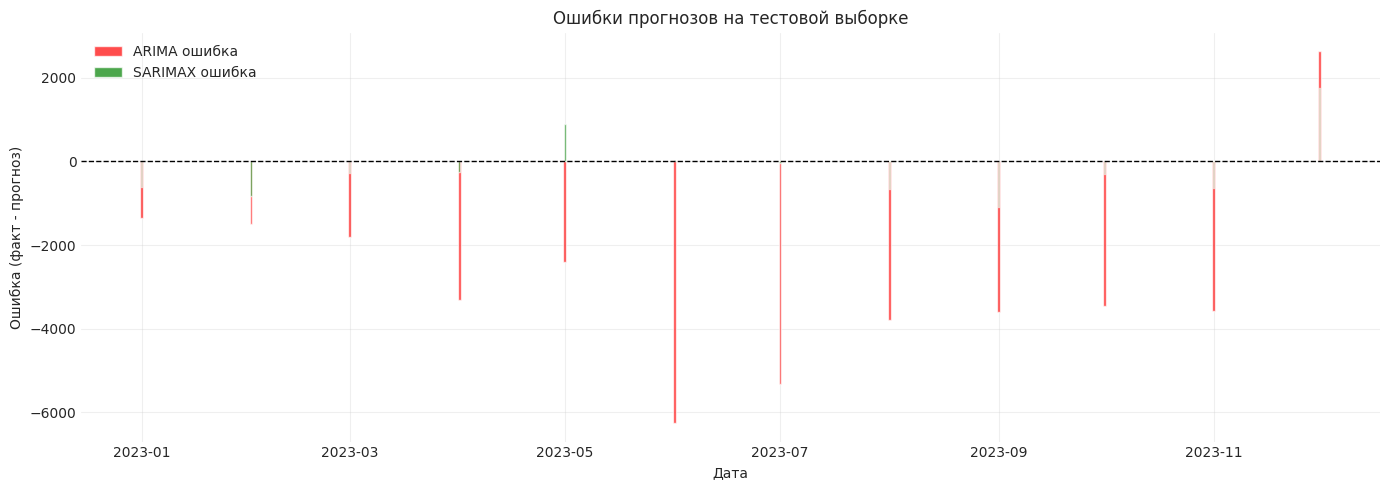

Средняя абсолютная ошибка ARIMA:   3254
Средняя абсолютная ошибка SARIMAX: 617


In [77]:
errors_arima = y_test.values - pred_arima.values
errors_sarimax = y_test.values - pred_sarimax.values

plt.figure(figsize=(14, 5))
plt.bar(y_test.index, errors_arima, alpha=0.7, label='ARIMA ошибка', color='red')
plt.bar(y_test.index, errors_sarimax, alpha=0.7, label='SARIMAX ошибка', color='green', width=0.4)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Ошибки прогнозов на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Ошибка (факт - прогноз)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Средняя абсолютная ошибка ARIMA:   {np.abs(errors_arima).mean():.0f}")
print(f"Средняя абсолютная ошибка SARIMAX: {np.abs(errors_sarimax).mean():.0f}")

### Анализ остатков

In [76]:
# Остатки моделей
resid_arima = arima_fit.resid.dropna()
resid_sarimax = sarimax_fit.resid.dropna()

# Тест Жарка-Бера (нормальность распределения)
jb_arima = jarque_bera(resid_arima)
jb_sarimax = jarque_bera(resid_sarimax)

# Тест Льюнга-Бокса (автокорреляция остатков)
lb_arima = acorr_ljungbox(resid_arima, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
lb_sarimax = acorr_ljungbox(resid_sarimax, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

# Тест ARCH (гетероскедастичность)
arch_arima = het_arch(resid_arima)[1]
arch_sarimax = het_arch(resid_sarimax)[1]

print("Диагностика остатков:")
print()
print(f"{'Тест':<25} {'ARIMA':<20} {'SARIMAX':<20}")
print()
print(f"{'Jarque-Bera p-value':<25} {jb_arima[1]:<20.4f} {jb_sarimax[1]:<20.4f}")
print(f"{'Ljung-Box p-value (lag=10)':<25} {lb_arima:<20.4f} {lb_sarimax:<20.4f}")
print(f"{'ARCH p-value':<25} {arch_arima:<20.4f} {arch_sarimax:<20.4f}")
print()
print("Интерпретация:")
print("  • Jarque-Bera: p < 0.05 → распределение не нормальное")
print("  • Ljung-Box:   p > 0.05 → автокорреляция отсутствует")
print("  • ARCH:        p > 0.05 → гомоскедастичность (нет изменчивости)")

Диагностика остатков:

Тест                      ARIMA                SARIMAX             

Jarque-Bera p-value       0.0000               0.0000              
Ljung-Box p-value (lag=10) 0.9299               0.8898              
ARCH p-value              0.7639               0.6823              

Интерпретация:
  • Jarque-Bera: p < 0.05 → распределение не нормальное
  • Ljung-Box:   p > 0.05 → автокорреляция отсутствует
  • ARCH:        p > 0.05 → гомоскедастичность (нет изменчивости)


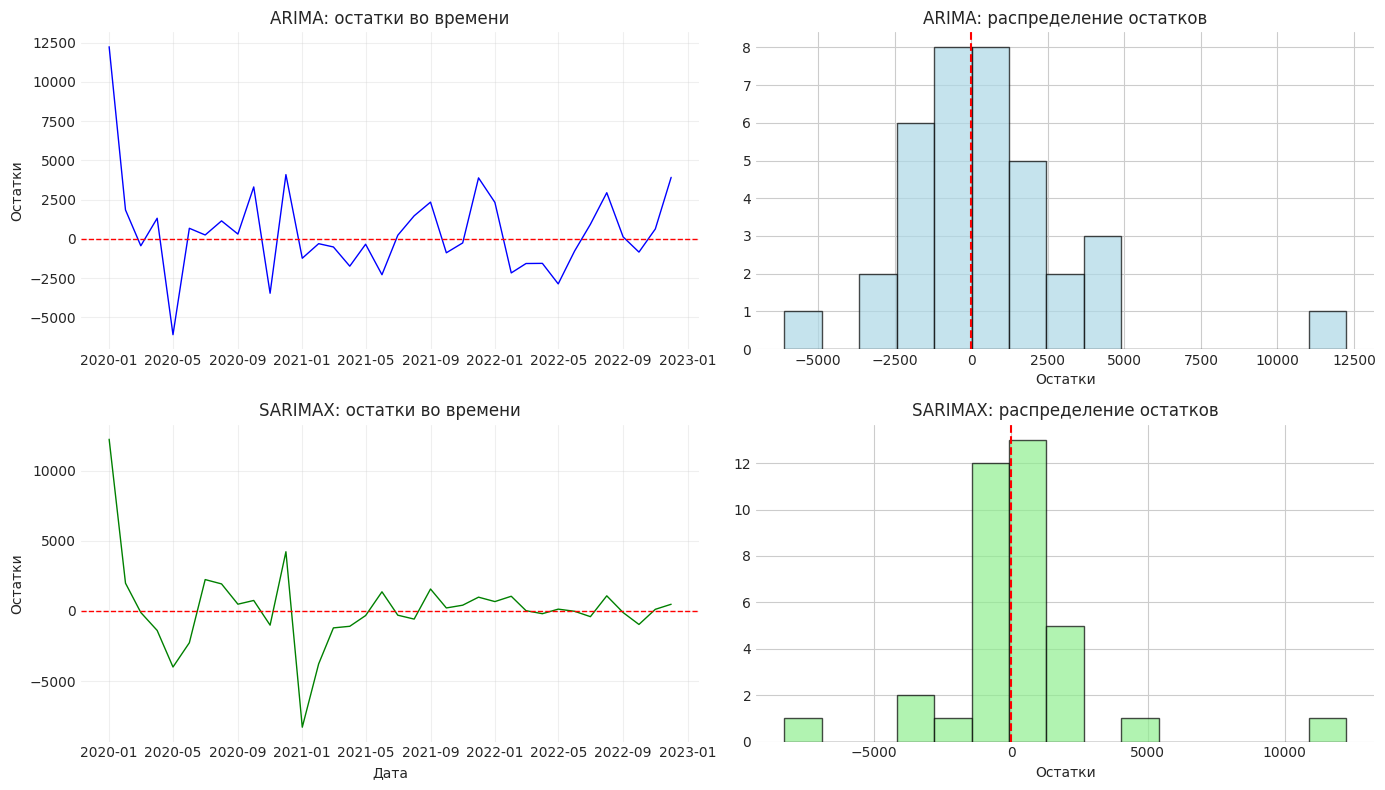

In [78]:
resid_arima = arima_fit.resid.dropna()
resid_sarimax = sarimax_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ARIMA остатки во времени
axes[0,0].plot(resid_arima.index, resid_arima.values, color='blue', linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('ARIMA: остатки во времени')
axes[0,0].set_ylabel('Остатки')
axes[0,0].grid(True, alpha=0.3)

# ARIMA гистограмма остатков
axes[0,1].hist(resid_arima, bins=15, edgecolor='black', color='lightblue', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title('ARIMA: распределение остатков')
axes[0,1].set_xlabel('Остатки')

# SARIMAX остатки во времени
axes[1,0].plot(resid_sarimax.index, resid_sarimax.values, color='green', linewidth=1)
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('SARIMAX: остатки во времени')
axes[1,0].set_ylabel('Остатки')
axes[1,0].set_xlabel('Дата')
axes[1,0].grid(True, alpha=0.3)

# SARIMAX гистограмма остатков
axes[1,1].hist(resid_sarimax, bins=15, edgecolor='black', color='lightgreen', alpha=0.7)
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('SARIMAX: распределение остатков')
axes[1,1].set_xlabel('Остатки')

plt.tight_layout()
plt.show()

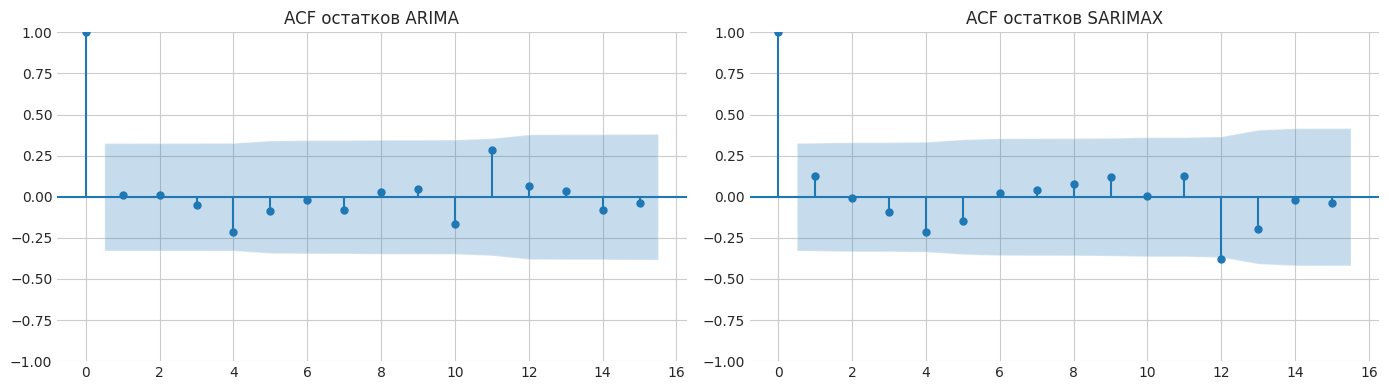

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(resid_arima, lags=15, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF остатков ARIMA')

plot_acf(resid_sarimax, lags=15, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF остатков SARIMAX')

plt.tight_layout()
plt.show()

Сравнение двух построенных моделей — ARIMA(1,1,1) и SARIMAX(1,1,1)(1,1,1,12) с экзогенными переменными Promotion и HolidayMonth — проводилось по нескольким критериям: метрики точности прогноза (MSE, R²), информационные критерии (AIC, BIC) и диагностика остатков (нормальность, автокорреляция, гомоскедастичность).

По метрикам точности. SARIMAX демонстрирует значительное превосходство. Среднеквадратичная ошибка (MSE) снижена с 12 562 581 у ARIMA до 604 746 у SARIMAX, что соответствует улучшению на 95%. Коэффициент детерминации R² у SARIMAX составляет 0.87, тогда как у ARIMA он отрицательный (-1.72), что указывает на полную непригодность ARIMA для прогнозирования данного ряда.

По информационным критериям. Значения AIC и BIC у SARIMAX (152.67 и 154.05) существенно ниже, чем у ARIMA (643.80 и 648.47). Разница более 490 пунктов является убедительным доказательством предпочтительности SARIMAX.

По диагностике остатков. Обе модели дают приемлемые результаты: автокорреляция остатков отсутствует (Ljung-Box p > 0.05), гомоскедастичность выполняется (ARCH p > 0.05). Нарушение нормальности распределения (Jarque-Bera p < 0.05) не является критичным для задач прогнозирования, так как модели не требуют строгой нормальности остатков.

Вывод. Модель SARIMAX(1,1,1)(1,1,1,12) с экзогенными переменными Promotion и HolidayMonth признаётся лучшей по всем критериям качества. ARIMA(1,1,1) не учитывает сезонность и экзогенные факторы, поэтому не может быть рекомендована для прогнозирования розничных продаж.

### Итоговый вывод
В ходе выполнения лабораторной работы проведён полный цикл анализа и прогнозирования временного ряда розничных продаж за период 2020–2023 гг. (48 ежемесячных наблюдений). Решены следующие задачи: разведочный анализ (EDA), декомпозиция ряда тремя методами (классическая, FFT, вейвлеты), построение и сравнение прогнозных моделей ARIMA и SARIMAX, оценка качества прогнозов.

По результатам EDA установлено, что ряд имеет ярко выраженную годовую сезонность: декабрьские продажи в среднем на 4300 единиц выше остальных месяцев. Переменные Promotion и HolidayMonth оказывают значимое влияние на объём продаж, хотя в мае 2021 года зафиксировано падение (-6.6%) на фоне акции. Тренд положительный — уровень продаж 2023 года выше, чем в 2020–2021.

Декомпозиция ряда тремя методами подтвердила наличие устойчивой сезонности с периодом 12 месяцев. FFT выявила доминирующий период 12 месяцев, вейвлет-анализ показал, что амплитуда сезонных колебаний увеличивается к концу периода наблюдений. STL оказалась наиболее робастной к выбросам. Сделан вывод о целесообразности использования сезонной модели.

Построены две прогнозные модели: ARIMA(1,1,1) и SARIMAX(1,1,1)(1,1,1,12) с экзогенными переменными Promotion и HolidayMonth. Прогноз выполнен на 12 месяцев (весь 2023 год).

Оценка качества показала, что SARIMAX значительно превосходит ARIMA по всем метрикам:

MSE снижена с 12 562 581 до 604 746 (улучшение на 95%);

R² повышен с -1.72 до 0.87;

AIC и BIC у SARIMAX ниже на 490 пунктов.

Диагностика остатков подтвердила корректность обеих моделей: автокорреляция отсутствует (Ljung-Box p > 0.05), гомоскедастичность выполняется (ARCH p > 0.05). Нарушение нормальности распределения (Jarque-Bera p < 0.05) допустимо для задач прогнозирования.

Заключение. Для прогнозирования розничных продаж на горизонте до 12 месяцев рекомендуется использовать модель SARIMAX(1,1,1)(1,1,1,12) с экзогенными переменными Promotion и HolidayMonth. Модель учитывает годовую сезонность, реагирует на акции и праздничные месяцы, демонстрирует высокое качество прогноза (R² = 0.87). ARIMA без учёта сезонности не может быть рекомендована для данного ряда. В качестве направления дальнейших исследований предлагается рассмотрение нелинейных методов (Prophet, LSTM) и добавление дополнительных экзогенных факторов (экономические индикаторы, цена товара).